# Brainify — Brain Tumor Segmentation & Classification 

**Dataset:** BraTS 2020 — 57,195 pre-sliced MRI scans (369 patients)

**Architecture:** Dual-Head Residual Attention U-Net with SE Blocks
| Head | Output | Loss |
|------|--------|------|
| Segmentation | 128×128 binary tumor mask | Dice + BCE |
| Classification | No Tumor / LGG / HGG | Label-Smoothed Categorical CE |

**Output:** `brain_tumor_unet.h5` — loads directly in the Django app



In [1]:
import os, sys, glob, time, warnings, json, csv
warnings.filterwarnings('ignore')

import numpy as np
import cv2
import h5py
import nibabel as nib
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, backend as K
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
from tqdm.auto import tqdm   # Auto-detect notebook vs terminal

print(f'TensorFlow: {tf.__version__}')
print(f'OpenCV:     {cv2.__version__}')
print(f'NumPy:      {np.__version__}')
print(f'h5py:       {h5py.__version__}')

# GPU check
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f'✅ GPU detected: {len(gpus)} device(s) — training will be fast')
else:
    print('⚠️  No GPU — training on CPU (slower but works fine)')

print('✅ All imports loaded')


TensorFlow: 2.19.0
OpenCV:     4.13.0
NumPy:      2.0.2
h5py:       3.15.1
✅ GPU detected: 1 device(s) — training will be fast
✅ All imports loaded


## Cell 0 — Colab Setup (skip if running locally)




In [2]:
# ══════════════════════════════════════════════════════
#  COLAB SETUP — skip this cell if running locally
# ══════════════════════════════════════════════════════
import os

# Detect if we're on Google Colab
IS_COLAB = 'COLAB_GPU' in os.environ or os.path.exists('/content')

if IS_COLAB:
    print('🔧 Running on Google Colab — setting up...')

    import subprocess, zipfile, requests
    from tqdm.notebook import tqdm

    # Install only nibabel (requests/tqdm already in Colab)
    subprocess.run(['pip', 'install', '-q', 'nibabel'], check=True)
    print('✅ Packages ready')

    # ── Load Kaggle token from Colab Secrets ──
    # Add it via the 🔑 key icon in the left sidebar:
    #   Name: KAGGLE_TOKEN   Value: your KGAT_... token
    from google.colab import userdata
    kaggle_token = userdata.get('KAGGLE_TOKEN')
    print('✅ Kaggle token loaded')

    # Download BraTS 2020 dataset via Kaggle REST API (no CLI needed)
    dataset_dir = os.path.expanduser('~/brainify_dataset')
    data_check = os.path.join(dataset_dir, 'BraTS2020_training_data', 'content', 'data', 'meta_data.csv')

    if not os.path.exists(data_check):
        print('\n📥 Downloading BraTS 2020 dataset (~7 GB) via Kaggle API...')
        os.makedirs(dataset_dir, exist_ok=True)
        zip_path = os.path.join(dataset_dir, 'brats2020.zip')

        url = 'https://www.kaggle.com/api/v1/datasets/download/awsaf49/brats2020-training-data'
        headers = {'Authorization': f'Bearer {kaggle_token}'}

        with requests.get(url, headers=headers, stream=True) as r:
            if r.status_code != 200:
                raise RuntimeError(f'Download failed (HTTP {r.status_code}): {r.text[:300]}')
            total = int(r.headers.get('content-length', 0))
            with open(zip_path, 'wb') as f, tqdm(total=total, unit='B', unit_scale=True, desc='Downloading') as bar:
                for chunk in r.iter_content(chunk_size=1024 * 1024):
                    f.write(chunk)
                    bar.update(len(chunk))

        print('📦 Extracting...')
        with zipfile.ZipFile(zip_path, 'r') as z:
            z.extractall(dataset_dir)
        os.remove(zip_path)
        print('✅ Dataset downloaded and extracted!')
    else:
        print('✅ Dataset already downloaded')

    # Create model output directory
    os.makedirs('/content/model_output', exist_ok=True)
    print('✅ Colab setup complete — T4 GPU ready for training!')
else:
    print('💻 Running locally — skipping Colab setup')


🔧 Running on Google Colab — setting up...
✅ Packages ready
✅ Kaggle token loaded

📥 Downloading BraTS 2020 dataset (~7 GB) via Kaggle API...


Downloading:   0%|          | 0.00/7.25G [00:00<?, ?B/s]

📦 Extracting...
✅ Dataset downloaded and extracted!
✅ Colab setup complete — T4 GPU ready for training!


## Cell 2 — Configuration

All training hyperparameters in one place.

| Parameter | Value | Why |
|-----------|-------|-----|
| `BATCH_SIZE` | 16 | Stable gradients on CPU/GPU |
| `EPOCHS` | 120 | Long runway — early stopping cuts when converged |
| `LEARNING_RATE` | 1e-3 | Cosine schedule with 8-epoch warmup |
| `MAX_TUMOR_SLICES` | 50 | Rich tumor diversity per patient |
| `LABEL_SMOOTHING` | 0.05 | Prevents overconfident wrong predictions |

In [3]:

# ============ TRAINING SETTINGS (V4 — Maximum Accuracy) ============
IMG_SIZE         = 128       # Image dimensions (128×128)
MAX_PATIENTS     = 369       # ALL patients in BraTS2020
MAX_TUMOR_SLICES = 50        # More tumor slices per patient (was 40)
NON_TUMOR_RATIO  = 0.15      # More negatives → better no-tumor learning

BATCH_SIZE       = 32        # Larger batch = faster on GPU + stable gradients
EPOCHS           = 100       # Long training — early stopping will cut if converged
LEARNING_RATE    = 1e-3      # Higher peak LR with cosine decay (warmup handles the start)
VAL_SPLIT        = 0.15      # Validation split
TEST_SPLIT       = 0.10      # Test split
RANDOM_SEED      = 42

# Loss weights — balanced for both tasks
SEG_LOSS_WEIGHT  = 1.5       # Segmentation primary
CLS_LOSS_WEIGHT  = 1.0       # Classification now gets proper gradient signal (was 0.5)

# Label smoothing for classification (prevents overconfident predictions)
LABEL_SMOOTHING  = 0.05

# ============ AUTO-DETECT ENVIRONMENT ============
IS_COLAB = 'COLAB_GPU' in os.environ or os.path.exists('/content')

# ============ PATHS (auto-detect Colab vs Local) ============
DATASET_DIR = os.path.expanduser('~/brainify_dataset')

POSSIBLE_DATA_ROOTS = [
    os.path.join(DATASET_DIR, 'BraTS2020_TrainingData', 'MICCAI_BraTS2020_TrainingData'),
    os.path.join(DATASET_DIR, 'MICCAI_BraTS2020_TrainingData'),
    os.path.join(DATASET_DIR, 'BraTS2020_TrainingData'),
    DATASET_DIR,
]

if IS_COLAB:
    # On Colab: save to /content/model_output, download later
    MODEL_SAVE_DIR = '/content/model_output'
    os.makedirs(MODEL_SAVE_DIR, exist_ok=True)
else:
    # On local Mac: save directly into Django core/ folder
    _this_dir = os.path.dirname(os.path.abspath('__file__'))
    _possible_core = [
        os.path.join(_this_dir, 'core'),
        os.path.join(_this_dir, '..', 'core'),
        os.path.expanduser('~/Desktop/brainifyfinal31/core'),
    ]
    MODEL_SAVE_DIR = next((p for p in _possible_core if os.path.isdir(os.path.abspath(p))), _possible_core[-1])
    MODEL_SAVE_DIR = os.path.abspath(MODEL_SAVE_DIR)

MODEL_PATH = os.path.join(MODEL_SAVE_DIR, 'brain_tumor_unet.h5')

CLASS_NAMES = ['No Tumor', 'LGG (Low-Grade)', 'HGG (High-Grade)']
NUM_CLASSES = 3

np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

print(f'✅ Config loaded (V4 — Maximum Accuracy)')
print(f'   Environment:      {"Google Colab" if IS_COLAB else "Local"}')
print(f'   Image size:       {IMG_SIZE}×{IMG_SIZE}')
print(f'   Max patients:     {MAX_PATIENTS} (all available)')
print(f'   Tumor slices/pt:  {MAX_TUMOR_SLICES}')
print(f'   Batch size:       {BATCH_SIZE}')
print(f'   Epochs:           {EPOCHS}')
print(f'   Learning rate:    {LEARNING_RATE} (with cosine + warmup)')
print(f'   Seg loss wt:      {SEG_LOSS_WEIGHT}')
print(f'   Cls loss wt:      {CLS_LOSS_WEIGHT}')
print(f'   Label smoothing:  {LABEL_SMOOTHING}')
print(f'   Model output:     {MODEL_PATH}')


✅ Config loaded (V4 — Maximum Accuracy)
   Environment:      Google Colab
   Image size:       128×128
   Max patients:     369 (all available)
   Tumor slices/pt:  50
   Batch size:       32
   Epochs:           100
   Learning rate:    0.001 (with cosine + warmup)
   Seg loss wt:      1.5
   Cls loss wt:      1.0
   Label smoothing:  0.05
   Model output:     /content/model_output/brain_tumor_unet.h5


## Cell 3 — Locate Dataset

Detects the BraTS 2020 dataset on disk. Supports both formats:
- **H5** (awsaf49 pre-sliced) — `meta_data.csv` + `volume_*_slice_*.h5`
- **NIfTI** (original BraTS20 patient folders) — `BraTS20_Training_*` directories

If the dataset is not found, prints manual download instructions.

In [4]:

# ══════════════════════════════════════════════════════
#  Locate BraTS 2020 dataset (no download — dataset already on disk)
# ══════════════════════════════════════════════════════

def find_existing_dataset():
    """Fast detection of BraTS 2020 dataset on disk."""

    # ── H5 format (awsaf49 pre-sliced): look for meta_data.csv ──
    h5_candidates = [
        os.path.join(DATASET_DIR, 'BraTS2020_training_data', 'content', 'data'),
        os.path.join(DATASET_DIR, 'content', 'data'),
        os.path.join(DATASET_DIR, 'data'),
        DATASET_DIR,
    ]
    for root in h5_candidates:
        meta_csv = os.path.join(root, 'meta_data.csv')
        if os.path.isfile(meta_csv):
            return root, 'h5'

    # ── NIfTI format (original BraTS20 patient folders) ──
    for root in POSSIBLE_DATA_ROOTS:
        if os.path.isdir(root) and glob.glob(os.path.join(root, 'BraTS20_Training_*')):
            return root, 'nifti'

    return None, None


DATA_ROOT, DATA_FORMAT = find_existing_dataset()

if DATA_ROOT:
    print(f'✅ Dataset found: {DATA_ROOT}')
    print(f'   Format: {DATA_FORMAT.upper()}')
    if DATA_FORMAT == 'h5':
        # Quick count from meta_data.csv (much faster than globbing 57k files)
        meta_csv = os.path.join(DATA_ROOT, 'meta_data.csv')
        with open(meta_csv, 'r') as f:
            n_slices = sum(1 for _ in f) - 1  # subtract header
        print(f'   Slices: {n_slices:,} (from meta_data.csv)')
    else:
        n_patients = len(glob.glob(os.path.join(DATA_ROOT, 'BraTS20_Training_*')))
        print(f'   Patients: {n_patients}')
else:
    print('❌ Dataset not found!')
    print()
    print('DOWNLOAD STEPS:')
    print('  1. Go to: https://www.kaggle.com/datasets/awsaf49/brats2020-training-data')
    print('  2. Click "Download" (≈7 GB zip)')
    print(f'  3. Unzip into: {DATASET_DIR}/')
    print('  4. Re-run this cell')
    raise SystemExit('Dataset not found — follow the download steps above')

print(f'\n   DATA_ROOT:   {DATA_ROOT}')
print(f'   DATA_FORMAT: {DATA_FORMAT}')


✅ Dataset found: /root/brainify_dataset/BraTS2020_training_data/content/data
   Format: H5
   Slices: 57,195 (from meta_data.csv)

   DATA_ROOT:   /root/brainify_dataset/BraTS2020_training_data/content/data
   DATA_FORMAT: h5


## Cell 4 — Preprocessing Functions (OpenCV)

| Step | Function | Purpose |
|------|----------|---------|
| CLAHE | `cv2.createCLAHE` | Enhances local contrast in MRI |
| Gaussian Blur | `cv2.GaussianBlur` | Reduces acquisition noise |
| Nearest Resize | `cv2.INTER_NEAREST` | Preserves sharp mask boundaries |
| Grade Detection | `determine_grade()` | Labels slices as LGG or HGG from enhancing-tumor ratio |

In [5]:
def preprocess_slice(img_slice, img_size=IMG_SIZE):
    """
    Preprocess a single 2D MRI slice using OpenCV.
    Pipeline: Resize → CLAHE → GaussianBlur → Normalize [0,1]
    """
    img = cv2.resize(img_slice.astype(np.float32), (img_size, img_size),
                     interpolation=cv2.INTER_LINEAR)

    img_min, img_max = img.min(), img.max()
    if img_max - img_min > 1e-6:
        img_uint8 = ((img - img_min) / (img_max - img_min) * 255).astype(np.uint8)
    else:
        img_uint8 = np.zeros((img_size, img_size), dtype=np.uint8)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img_clahe = clahe.apply(img_uint8)
    img_smooth = cv2.GaussianBlur(img_clahe, (3, 3), 0)
    img_final = img_smooth.astype(np.float32) / 255.0

    return img_final


def preprocess_mask(mask_slice, img_size=IMG_SIZE):
    """
    Preprocess segmentation mask.
    BraTS labels: 0=background, 1=NCR/NET, 2=Edema, 4=Enhancing Tumor
    → Binary: any tumor label > 0 becomes 1
    """
    binary = (mask_slice > 0).astype(np.float32)
    binary_resized = cv2.resize(binary, (img_size, img_size),
                                interpolation=cv2.INTER_NEAREST)
    return binary_resized


def determine_grade(seg_volume):
    """
    Determine tumor grade from 3D segmentation volume.
    HGG: significant enhancing tumor (label 4)
    LGG: mostly non-enhancing (labels 1, 2)
    """
    total_tumor = np.sum(seg_volume > 0)
    enhancing = np.sum(seg_volume == 4)

    if total_tumor < 200:
        return 0  # No significant tumor

    enhancing_ratio = enhancing / (total_tumor + 1e-6)
    if enhancing_ratio > 0.05 or enhancing > 500:
        return 2  # HGG
    else:
        return 1  # LGG


print('✅ Preprocessing functions defined')

✅ Preprocessing functions defined


## Cell 5 — Data Augmentation (OpenCV)

Strong augmentations applied to each image + mask pair:

| Augmentation | Range | Probability |
|---|---|---|
| Horizontal flip | — | 50% |
| Vertical flip | — | 20% |
| Rotation | ±25° | 65% |
| Translation | ±15% | 55% |
| Zoom | 0.80–1.20× | 55% |
| Perspective warp | ±5% | 25% |
| Gamma correction | 0.6–1.5 | 45% |
| Brightness/contrast | α 0.75–1.25, β ±0.12 | 55% |
| Gaussian noise | σ = 0.03 | 45% |
| Gaussian blur | k = 3 or 5 | 20% |

In [6]:

def augment_pair(image, mask):
    """Apply strong random augmentations to an image-mask pair using OpenCV."""
    h, w = image.shape[:2]

    # Random Horizontal Flip (50%)
    if np.random.random() > 0.5:
        image = cv2.flip(image, 1)
        mask = cv2.flip(mask, 1)

    # Random Vertical Flip (20%)
    if np.random.random() > 0.8:
        image = cv2.flip(image, 0)
        mask = cv2.flip(mask, 0)

    # Random Rotation ±25° (65%)
    if np.random.random() > 0.35:
        angle = np.random.uniform(-25, 25)
        M = cv2.getRotationMatrix2D((w / 2, h / 2), angle, 1.0)
        image = cv2.warpAffine(image, M, (w, h), borderMode=cv2.BORDER_REFLECT)
        mask = cv2.warpAffine(mask, M, (w, h), flags=cv2.INTER_NEAREST,
                              borderMode=cv2.BORDER_CONSTANT, borderValue=0)

    # Random Shift ±15% (55%)
    if np.random.random() > 0.45:
        tx = np.random.uniform(-0.15, 0.15) * w
        ty = np.random.uniform(-0.15, 0.15) * h
        M = np.float32([[1, 0, tx], [0, 1, ty]])
        image = cv2.warpAffine(image, M, (w, h), borderMode=cv2.BORDER_REFLECT)
        mask = cv2.warpAffine(mask, M, (w, h), flags=cv2.INTER_NEAREST,
                              borderMode=cv2.BORDER_CONSTANT, borderValue=0)

    # Random Zoom 0.80–1.20× (55%)
    if np.random.random() > 0.45:
        scale = np.random.uniform(0.80, 1.20)
        M = cv2.getRotationMatrix2D((w / 2, h / 2), 0, scale)
        image = cv2.warpAffine(image, M, (w, h), borderMode=cv2.BORDER_REFLECT)
        mask = cv2.warpAffine(mask, M, (w, h), flags=cv2.INTER_NEAREST,
                              borderMode=cv2.BORDER_CONSTANT, borderValue=0)

    # Elastic-like distortion via random perspective (25%)
    if np.random.random() > 0.75:
        dx = np.random.uniform(-0.05, 0.05) * w
        dy = np.random.uniform(-0.05, 0.05) * h
        src = np.float32([[0,0],[w,0],[0,h],[w,h]])
        dst = np.float32([[dx,dy],[w-dx,dy],[dx,h-dy],[w-dx,h-dy]])
        M_persp = cv2.getPerspectiveTransform(src, dst)
        image = cv2.warpPerspective(image, M_persp, (w,h), borderMode=cv2.BORDER_REFLECT)
        mask = cv2.warpPerspective(mask, M_persp, (w,h), flags=cv2.INTER_NEAREST,
                                   borderMode=cv2.BORDER_CONSTANT, borderValue=0)

    # Gamma correction — image only (45%)
    if np.random.random() > 0.55:
        gamma = np.random.uniform(0.6, 1.5)
        image = np.clip(np.power(image + 1e-7, gamma), 0, 1).astype(np.float32)

    # Random Brightness/Contrast — image only (55%)
    if np.random.random() > 0.45:
        alpha = np.random.uniform(0.75, 1.25)
        beta = np.random.uniform(-0.12, 0.12)
        image = np.clip(alpha * image + beta, 0, 1).astype(np.float32)

    # Random Gaussian Noise — image only (45%)
    if np.random.random() > 0.55:
        noise = np.random.normal(0, 0.03, image.shape).astype(np.float32)
        image = np.clip(image + noise, 0, 1).astype(np.float32)

    # Random blur — image only (20%)
    if np.random.random() > 0.80:
        ksize = np.random.choice([3, 5])
        image = cv2.GaussianBlur(image, (ksize, ksize), 0)

    mask = (mask > 0.5).astype(np.float32)
    return image, mask


print('✅ Augmentation functions defined (V4 — stronger + random blur)')


✅ Augmentation functions defined (V4 — stronger + random blur)


## Cell 6 — Load & Preprocess BraTS 2020

Reads H5 slices (or NIfTI volumes) and builds the training arrays:
- Uses **FLAIR** modality (best contrast for tumor boundaries)
- Quality filter: skips slices with < 5% brain content
- Grade labels from `name_mapping.csv` (HGG vs LGG)

**⏳ Takes 5–15 min** depending on disk speed and `MAX_PATIENTS`.

In [7]:

# ─────────────────────────────────────────────────────
#  H5 Loader  (awsaf49/brats2020-training-data format)
# ─────────────────────────────────────────────────────
def load_brats_h5_dataset(data_dir):
    """
    Load the awsaf49 pre-sliced H5 dataset.
    Each .h5 file:  image (240×240×4 float64),  mask (240×240×3) uint8
    meta_data.csv:  slice_path, target(0/1), volume, slice
    name_mapping.csv: Grade(HGG/LGG), BraTS_2020_subject_ID

    Returns X (N,128,128,1), Y_seg (N,128,128,1), Y_cls (N,3)
    """
    meta_csv   = os.path.join(data_dir, 'meta_data.csv')
    name_csv   = os.path.join(data_dir, 'name_mapping.csv')

    # Build grade map:  volume_int → 1 (LGG) or 2 (HGG)
    grade_map = {}
    if os.path.exists(name_csv):
        with open(name_csv, 'r') as f:
            for row in csv.DictReader(f):
                subj  = row.get('BraTS_2020_subject_ID', '')
                grade = row.get('Grade', '')
                try:
                    vol_num = int(subj.split('_')[-1])
                    grade_map[vol_num] = 2 if grade.upper() == 'HGG' else 1
                except Exception:
                    pass
        print(f'  ✓ Grade mapping: {len(grade_map)} subjects')

    # Read all rows from meta_data.csv
    with open(meta_csv, 'r') as f:
        all_rows = list(csv.DictReader(f))

    tumor_rows    = [r for r in all_rows if int(r['target']) == 1]
    no_tumor_rows = [r for r in all_rows if int(r['target']) == 0]
    np.random.shuffle(tumor_rows)
    np.random.shuffle(no_tumor_rows)

    # V2: Load MORE data for better accuracy
    max_tumor    = MAX_PATIENTS * MAX_TUMOR_SLICES
    max_no_tumor = int(max_tumor * NON_TUMOR_RATIO / (1 - NON_TUMOR_RATIO))

    selected = (tumor_rows[:max_tumor] + no_tumor_rows[:max_no_tumor])
    np.random.shuffle(selected)
    print(f'  Sampling {len(selected):,} slices '
          f'({min(len(tumor_rows), max_tumor):,} tumor + '
          f'{min(len(no_tumor_rows), max_no_tumor):,} non-tumor)')

    images, masks, labels = [], [], []
    skipped = 0

    for row in tqdm(selected, desc='Loading slices'):
        h5_name = os.path.basename(row['slice_path'])
        h5_path = os.path.join(data_dir, h5_name)
        target  = int(row['target'])
        vol_num = int(row['volume'])

        try:
            with h5py.File(h5_path, 'r') as hf:
                img_raw  = hf['image'][..., 0].astype(np.float32)  # FLAIR channel (240×240)
                mask_raw = hf['mask'][...]                           # (240×240×3) uint8
        except Exception:
            skipped += 1
            continue

        img_proc = preprocess_slice(img_raw)
        msk_2d   = (mask_raw.max(axis=-1) > 0).astype(np.float32)  # binary (240×240)
        msk_proc = preprocess_mask(msk_2d)

        # Quality filter: skip slices where brain content is too low
        if img_proc.mean() < 0.05:
            skipped += 1
            continue

        if target == 0:
            label = 0
        else:
            label = grade_map.get(vol_num, 2)   # default HGG if volume not in mapping

        images.append(img_proc)
        masks.append(msk_proc)
        labels.append(label)

    print(f'\n  Loaded {len(images):,} slices  (skipped {skipped})')

    X     = np.array(images, dtype=np.float32)[..., np.newaxis]
    Y_seg = np.array(masks,  dtype=np.float32)[..., np.newaxis]
    Y_cls = to_categorical(np.array(labels, dtype=np.int32), NUM_CLASSES)

    label_arr = np.array(labels)
    for c in range(NUM_CLASSES):
        cnt = np.sum(label_arr == c)
        print(f'  Class {c} ({CLASS_NAMES[c]}): {cnt} slices ({cnt/len(labels)*100:.1f}%)')

    return X, Y_seg, Y_cls


# ─────────────────────────────────────────────────────
#  NIfTI Loader  (original BraTS20 patient folders)
# ─────────────────────────────────────────────────────
def load_brats_nifti_dataset(data_root):
    grade_map = {}
    csv_candidates = (glob.glob(os.path.join(data_root, '..', 'name_mapping.csv')) +
                      glob.glob(os.path.join(data_root, 'name_mapping.csv')))
    for csv_file in csv_candidates:
        try:
            with open(csv_file, 'r') as f:
                for row in csv.DictReader(f):
                    sid   = row.get('BraTS_2020_subject_ID', row.get('BraTS20_ID', ''))
                    grade = row.get('Grade', '')
                    if sid and grade:
                        grade_map[sid] = 2 if grade.upper() == 'HGG' else 1
            print(f'  ✓ Grade mapping: {len(grade_map)} entries from {csv_file}')
            break
        except Exception:
            pass

    patient_dirs = sorted(glob.glob(os.path.join(data_root, 'BraTS20_Training_*')))
    if not patient_dirs:
        patient_dirs = sorted(glob.glob(os.path.join(data_root, '*', 'BraTS20_Training_*')))
    patient_dirs = patient_dirs[:MAX_PATIENTS]
    print(f'  Found {len(patient_dirs)} patient directories')

    images, masks, labels = [], [], []
    skipped = 0

    for pdir in tqdm(patient_dirs, desc='Loading patients'):
        pid = os.path.basename(pdir)
        flair_files = glob.glob(os.path.join(pdir, '*flair*'))
        seg_files   = glob.glob(os.path.join(pdir, '*seg*'))
        if not flair_files or not seg_files:
            skipped += 1; continue
        try:
            flair_vol = nib.load(flair_files[0]).get_fdata().astype(np.float32)
            seg_vol   = nib.load(seg_files[0]).get_fdata().astype(np.float32)
        except Exception as e:
            print(f'  ⚠ {pid}: {e}'); skipped += 1; continue

        patient_grade = grade_map.get(pid, determine_grade(seg_vol))
        tumor_count   = 0

        for s in range(flair_vol.shape[2]):
            flair_slice = flair_vol[:, :, s]
            seg_slice   = seg_vol[:,  :, s]
            if np.sum(flair_slice > 0) < 1000:
                continue
            tumor_pixels = np.sum(seg_slice > 0)
            if tumor_pixels > 50:
                if tumor_count >= MAX_TUMOR_SLICES: continue
                slice_label = patient_grade; tumor_count += 1
            else:
                if np.random.random() > NON_TUMOR_RATIO: continue
                slice_label = 0
            images.append(preprocess_slice(flair_slice))
            masks.append(preprocess_mask(seg_slice))
            labels.append(slice_label)

    print(f'\n  Loaded {len(images)} slices from {len(patient_dirs)-skipped} patients')
    X     = np.array(images, dtype=np.float32)[..., np.newaxis]
    Y_seg = np.array(masks,  dtype=np.float32)[..., np.newaxis]
    Y_cls = to_categorical(np.array(labels, dtype=np.int32), NUM_CLASSES)
    label_arr = np.array(labels)
    for c in range(NUM_CLASSES):
        cnt = np.sum(label_arr == c)
        print(f'  Class {c} ({CLASS_NAMES[c]}): {cnt} slices ({cnt/len(labels)*100:.1f}%)')
    return X, Y_seg, Y_cls


# ─────────────────────────────────────────────────────
#  Run the appropriate loader
# ─────────────────────────────────────────────────────
print('Loading BraTS 2020 dataset (V2 — loading ALL patients)...')
t0 = time.time()

if DATA_FORMAT == 'h5':
    X, Y_seg, Y_cls = load_brats_h5_dataset(DATA_ROOT)
else:
    X, Y_seg, Y_cls = load_brats_nifti_dataset(DATA_ROOT)

print(f'\n✅ Dataset loaded in {time.time()-t0:.0f}s')
print(f'   X shape:     {X.shape}')
print(f'   Y_seg shape: {Y_seg.shape}')
print(f'   Y_cls shape: {Y_cls.shape}')
print(f'   Memory:      {(X.nbytes + Y_seg.nbytes + Y_cls.nbytes) / 1e9:.2f} GB')


Loading BraTS 2020 dataset (V2 — loading ALL patients)...
  ✓ Grade mapping: 369 subjects
  Sampling 21,705 slices (18,450 tumor + 3,255 non-tumor)


Loading slices:   0%|          | 0/21705 [00:00<?, ?it/s]


  Loaded 20,070 slices  (skipped 1635)
  Class 0 (No Tumor): 1928 slices (9.6%)
  Class 1 (LGG (Low-Grade)): 3630 slices (18.1%)
  Class 2 (HGG (High-Grade)): 14512 slices (72.3%)

✅ Dataset loaded in 202s
   X shape:     (20070, 128, 128, 1)
   Y_seg shape: (20070, 128, 128, 1)
   Y_cls shape: (20070, 3)
   Memory:      2.63 GB


## Cell 7 — Preview Samples

Visual sanity check — 4 random slices from each class (No Tumor / LGG / HGG) with red tumor overlay.

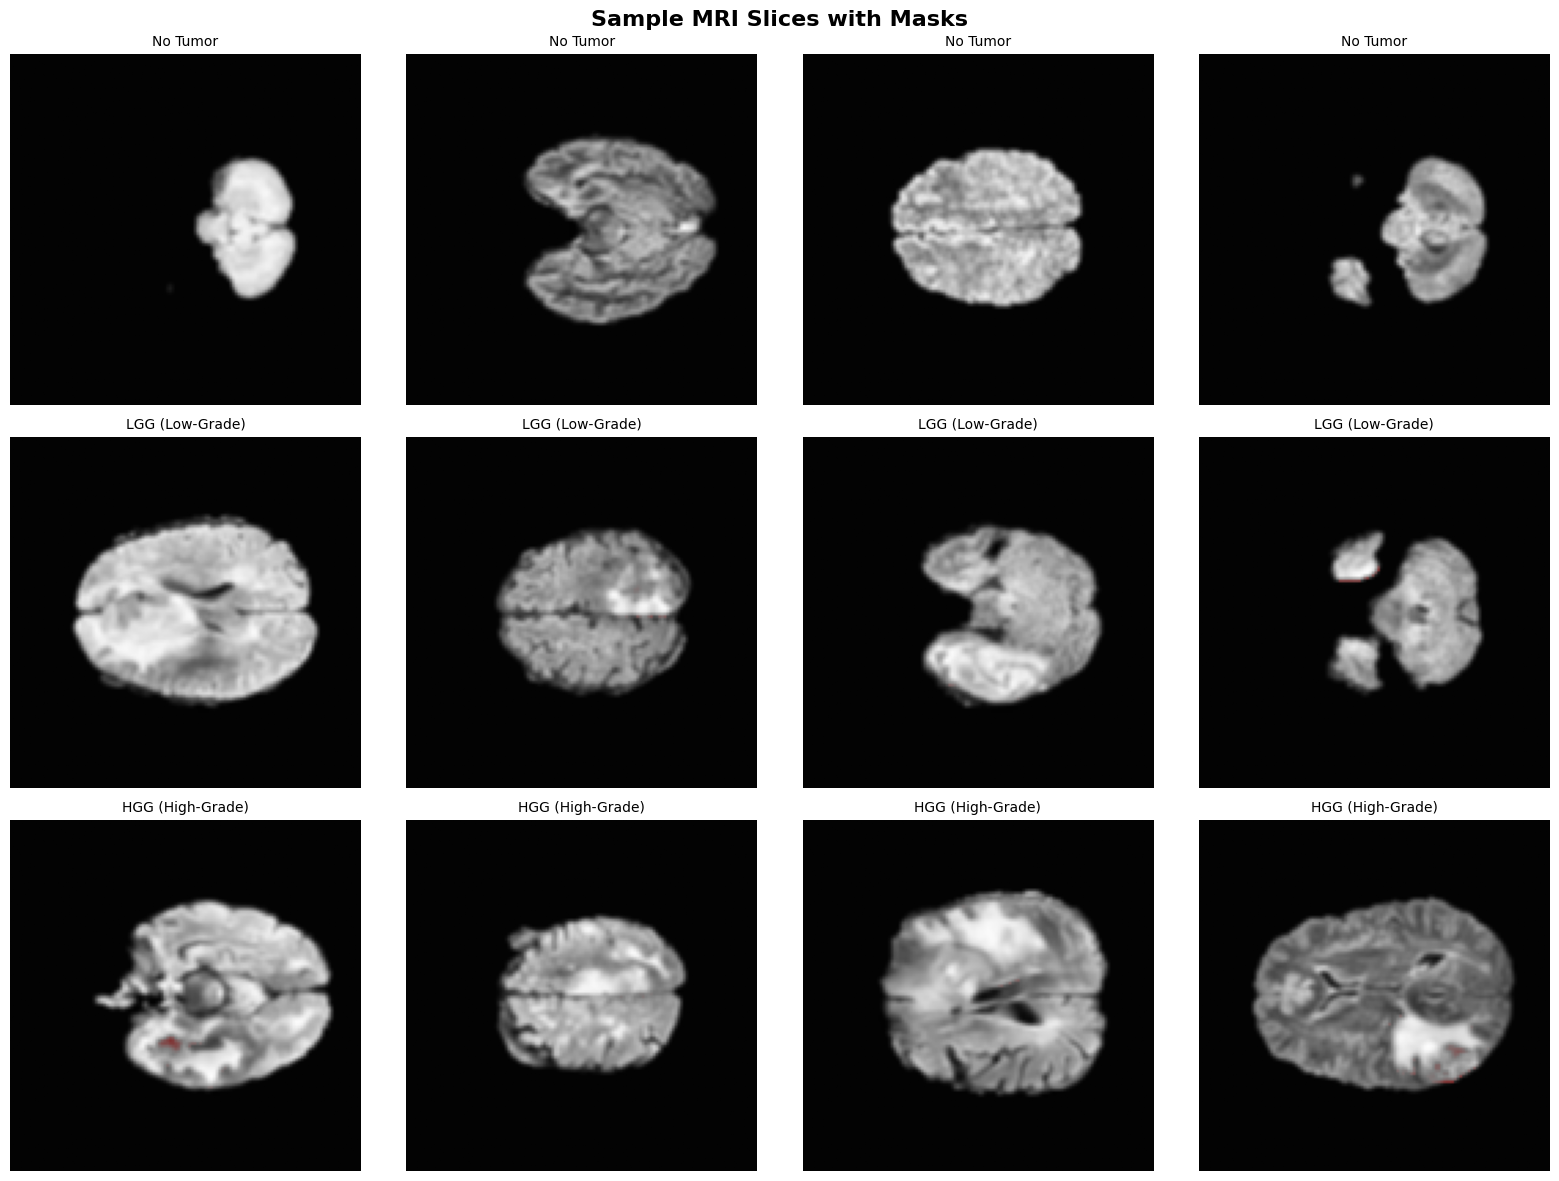

Red overlay = tumor region


In [8]:
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
fig.suptitle('Sample MRI Slices with Masks', fontsize=16, fontweight='bold')

# Pick some slices from each class
for row, cls_idx in enumerate([0, 1, 2]):
    indices = np.where(Y_cls.argmax(1) == cls_idx)[0]
    if len(indices) == 0:
        continue
    samples = np.random.choice(indices, min(4, len(indices)), replace=False)
    for col, idx in enumerate(samples[:4]):
        if col >= 4:
            break
        ax = axes[row, col]
        img = X[idx, :, :, 0]
        msk = Y_seg[idx, :, :, 0]

        # Overlay mask on image
        overlay = np.stack([img]*3, axis=-1)
        overlay[:, :, 0] = np.maximum(overlay[:, :, 0], msk * 0.5)

        ax.imshow(overlay)
        ax.set_title(f'{CLASS_NAMES[cls_idx]}', fontsize=10)
        ax.axis('off')

plt.tight_layout()
plt.show()
print('Red overlay = tumor region')

## Cell 8 — Train / Val / Test Split + On-the-fly Augmentation

| Split | Ratio | Purpose |
|-------|-------|---------|
| Train | 75% | Model learns from these |
| Val | 15% | Monitors overfitting each epoch |
| Test | 10% | Final evaluation (never seen during training) |

**Augmentation strategy (memory-safe, on-the-fly):**
- Tumor slices → **2× augmented** per epoch (doubles tumor diversity)
- Non-tumor slices → **30% augmented** (strengthens negative learning)
- No pre-allocated arrays → **zero extra RAM**


In [9]:

# ─────────────────────────────────────────────────────
#  V4: Split + On-the-fly Augmentation (NO pre-allocation)
# ─────────────────────────────────────────────────────
from tensorflow.keras.utils import Sequence as KerasSequence

# Split into train+val and test
X_trainval, X_test, Ys_trainval, Ys_test, Yc_trainval, Yc_test = train_test_split(
    X, Y_seg, Y_cls, test_size=TEST_SPLIT, random_state=RANDOM_SEED, stratify=Y_cls.argmax(1)
)

# Split train+val into train and val
X_train, X_val, Ys_train, Ys_val, Yc_train, Yc_val = train_test_split(
    X_trainval, Ys_trainval, Yc_trainval,
    test_size=VAL_SPLIT / (1 - TEST_SPLIT),
    random_state=RANDOM_SEED,
    stratify=Yc_trainval.argmax(1)
)

# Free the big pre-split arrays immediately
del X, Y_seg, Y_cls, X_trainval, Ys_trainval, Yc_trainval
import gc; gc.collect()

print(f'  Train: {X_train.shape[0]}  |  Val: {X_val.shape[0]}  |  Test: {X_test.shape[0]}')


# ── On-the-fly Augmented Data Generator ──────────────
class AugmentedSequence(KerasSequence):
    """Yields augmented batches on-the-fly — zero extra memory."""

    def __init__(self, X, Y_seg, Y_cls, batch_size=32,
                 tumor_aug=2, non_tumor_prob=0.30, shuffle=True):
        self.X = X
        self.Y_seg = Y_seg
        self.Y_cls = Y_cls
        self.bs = batch_size
        self.tumor_aug = tumor_aug          # extra copies per tumor slice
        self.non_tumor_prob = non_tumor_prob # prob of augmenting a non-tumor slice
        self.shuffle = shuffle

        # Build an expanded index list (original idx, is_augmented)
        self._build_index()

    def _build_index(self):
        idx = []
        for i in range(len(self.X)):
            idx.append((i, False))  # original
            label = self.Y_cls[i].argmax()
            if label > 0:
                for _ in range(self.tumor_aug):
                    idx.append((i, True))
            elif np.random.random() < self.non_tumor_prob:
                idx.append((i, True))
        self.indices = idx
        if self.shuffle:
            np.random.shuffle(self.indices)

    def __len__(self):
        return int(np.ceil(len(self.indices) / self.bs))

    def __getitem__(self, batch_idx):
        start = batch_idx * self.bs
        end = min(start + self.bs, len(self.indices))
        batch_indices = self.indices[start:end]

        Xb, Ysb, Ycb = [], [], []
        for orig_idx, do_aug in batch_indices:
            img = self.X[orig_idx, :, :, 0].copy()
            msk = self.Y_seg[orig_idx, :, :, 0].copy()
            cls_label = self.Y_cls[orig_idx].copy()

            if do_aug:
                img, msk = augment_pair(img, msk)

            Xb.append(img[..., np.newaxis])
            Ysb.append(msk[..., np.newaxis])
            Ycb.append(cls_label)

        return (
            np.array(Xb, dtype=np.float32),
            {
                'segmentation': np.array(Ysb, dtype=np.float32),
                'classification': np.array(Ycb, dtype=np.float32),
            }
        )

    def on_epoch_end(self):
        self._build_index()  # re-shuffle + re-sample non-tumor augs


# Create generators
train_seq = AugmentedSequence(
    X_train, Ys_train, Yc_train,
    batch_size=BATCH_SIZE, tumor_aug=2, non_tumor_prob=0.30, shuffle=True
)
val_seq = AugmentedSequence(
    X_val, Ys_val, Yc_val,
    batch_size=BATCH_SIZE, tumor_aug=0, non_tumor_prob=0.0, shuffle=False
)

# Count effective samples
train_labels = [train_seq.Y_cls[i].argmax() for i, _ in train_seq.indices]
for c in range(NUM_CLASSES):
    cnt = sum(1 for l in train_labels if l == c)
    print(f'  Class {c} ({CLASS_NAMES[c]}): {cnt:,} samples')
print(f'\n✅ On-the-fly augmentation ready — {len(train_seq.indices):,} train / {len(val_seq.indices):,} val')
print(f'   Batches per epoch: {len(train_seq)} train, {len(val_seq)} val')
print(f'   🧠 Memory-safe: no pre-allocated augmented arrays')


  Train: 15052  |  Val: 3011  |  Test: 2007
  Class 0 (No Tumor): 1,879 samples
  Class 1 (LGG (Low-Grade)): 8,166 samples
  Class 2 (HGG (High-Grade)): 32,652 samples

✅ On-the-fly augmentation ready — 42,697 train / 3,011 val
   Batches per epoch: 1335 train, 95 val
   🧠 Memory-safe: no pre-allocated augmented arrays


## Cell 9 — Build Model (Residual Attention U-Net)

```
Input 128×128×1
 │
 ├── ENCODER (4 levels: 32→64→128→256)
 │     ResConvBlock → Squeeze-Excite → MaxPool → SpatialDropout
 │
 ├── BOTTLENECK (512 filters + Dropout 0.3)
 │
 ├── CLASSIFICATION HEAD
 │     GlobalAvgPool + GlobalMaxPool → Dense 256 → Dense 128 → Softmax(3)
 │
 └── DECODER (4 levels with Attention Gates)
       UpSample → AttentionGate(skip) → Concat → ResConvBlock → SE
       → Conv(1, sigmoid) → 128×128×1 binary mask
```

Low dropout throughout (0.05–0.35) to prevent underfitting on medical data.

In [10]:

# ─────────────────────────────────────────────────────
#  V4 Model: Residual Attention U-Net — tuned for max accuracy
# ─────────────────────────────────────────────────────
from tensorflow.keras import regularizers

WEIGHT_DECAY = 1e-4

def residual_conv_block(x, filters, kernel_size=3):
    """Residual double-conv: Conv→BN→ReLU→Conv→BN + residual shortcut → ReLU"""
    shortcut = layers.Conv2D(filters, 1, padding='same',
                             kernel_regularizer=regularizers.l2(WEIGHT_DECAY))(x)
    shortcut = layers.BatchNormalization()(shortcut)

    x = layers.Conv2D(filters, kernel_size, padding='same', kernel_initializer='he_normal',
                       kernel_regularizer=regularizers.l2(WEIGHT_DECAY))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    x = layers.Conv2D(filters, kernel_size, padding='same', kernel_initializer='he_normal',
                       kernel_regularizer=regularizers.l2(WEIGHT_DECAY))(x)
    x = layers.BatchNormalization()(x)

    x = layers.Add()([x, shortcut])
    x = layers.Activation('relu')(x)
    return x


def squeeze_excite_block(x, ratio=16):
    """Squeeze-and-Excitation: channel attention for better feature recalibration."""
    filters = x.shape[-1]
    se = layers.GlobalAveragePooling2D()(x)
    se = layers.Dense(max(filters // ratio, 4), activation='relu',
                       kernel_initializer='he_normal')(se)
    se = layers.Dense(filters, activation='sigmoid',
                       kernel_initializer='he_normal')(se)
    se = layers.Reshape((1, 1, filters))(se)
    return layers.Multiply()([x, se])


def attention_gate(skip, gating, filters):
    """Attention Gate — focuses decoder on relevant spatial regions."""
    W_skip = layers.Conv2D(filters, 1, padding='same',
                            kernel_regularizer=regularizers.l2(WEIGHT_DECAY))(skip)
    W_skip = layers.BatchNormalization()(W_skip)

    W_gate = layers.Conv2D(filters, 1, padding='same',
                            kernel_regularizer=regularizers.l2(WEIGHT_DECAY))(gating)
    W_gate = layers.BatchNormalization()(W_gate)

    psi = layers.Activation('relu')(layers.Add()([W_skip, W_gate]))
    psi = layers.Conv2D(1, 1, padding='same', activation='sigmoid')(psi)
    return layers.Multiply()([skip, psi])


def build_brainify_unet_v4(input_shape=(IMG_SIZE, IMG_SIZE, 1), num_classes=NUM_CLASSES):
    """Build Brainify V4 — tuned for maximum accuracy."""
    inputs = layers.Input(input_shape, name='input_image')

    # ═══ ENCODER ═══
    e1 = residual_conv_block(inputs, 32)
    e1 = squeeze_excite_block(e1)
    p1 = layers.MaxPooling2D((2, 2))(e1)
    p1 = layers.SpatialDropout2D(0.05)(p1)   # V4: reduced from 0.1

    e2 = residual_conv_block(p1, 64)
    e2 = squeeze_excite_block(e2)
    p2 = layers.MaxPooling2D((2, 2))(e2)
    p2 = layers.SpatialDropout2D(0.05)(p2)   # V4: reduced from 0.1

    e3 = residual_conv_block(p2, 128)
    e3 = squeeze_excite_block(e3)
    p3 = layers.MaxPooling2D((2, 2))(e3)
    p3 = layers.SpatialDropout2D(0.08)(p3)   # V4: reduced from 0.15

    e4 = residual_conv_block(p3, 256)
    e4 = squeeze_excite_block(e4)
    p4 = layers.MaxPooling2D((2, 2))(e4)
    p4 = layers.SpatialDropout2D(0.1)(p4)    # V4: reduced from 0.2

    # ═══ BOTTLENECK ═══
    bn = residual_conv_block(p4, 512)
    bn = squeeze_excite_block(bn)
    bn = layers.Dropout(0.3)(bn)             # V4: reduced from 0.4

    # ═══ CLASSIFICATION HEAD (with Global Avg + Max pooling for richer features) ═══
    cls_avg = layers.GlobalAveragePooling2D()(bn)
    cls_max = layers.GlobalMaxPooling2D()(bn)
    cls = layers.Concatenate()([cls_avg, cls_max])  # V4: dual pooling = 1024 features
    cls = layers.Dense(256, activation='relu', kernel_initializer='he_normal',
                       kernel_regularizer=regularizers.l2(WEIGHT_DECAY))(cls)
    cls = layers.BatchNormalization()(cls)
    cls = layers.Dropout(0.35)(cls)          # V4: reduced from 0.5
    cls = layers.Dense(128, activation='relu', kernel_initializer='he_normal',
                       kernel_regularizer=regularizers.l2(WEIGHT_DECAY))(cls)
    cls = layers.BatchNormalization()(cls)
    cls = layers.Dropout(0.25)(cls)          # V4: reduced from 0.4
    cls_output = layers.Dense(num_classes, activation='softmax', name='classification')(cls)

    # ═══ DECODER (with Attention Gates + SE) ═══
    u4 = layers.UpSampling2D((2, 2))(bn)
    a4 = attention_gate(e4, u4, 256)
    u4 = layers.Concatenate()([u4, a4])
    d4 = residual_conv_block(u4, 256)
    d4 = squeeze_excite_block(d4)

    u3 = layers.UpSampling2D((2, 2))(d4)
    a3 = attention_gate(e3, u3, 128)
    u3 = layers.Concatenate()([u3, a3])
    d3 = residual_conv_block(u3, 128)
    d3 = squeeze_excite_block(d3)

    u2 = layers.UpSampling2D((2, 2))(d3)
    a2 = attention_gate(e2, u2, 64)
    u2 = layers.Concatenate()([u2, a2])
    d2 = residual_conv_block(u2, 64)
    d2 = squeeze_excite_block(d2)

    u1 = layers.UpSampling2D((2, 2))(d2)
    a1 = attention_gate(e1, u1, 32)
    u1 = layers.Concatenate()([u1, a1])
    d1 = residual_conv_block(u1, 32)
    d1 = squeeze_excite_block(d1)

    # ═══ SEGMENTATION OUTPUT ═══
    seg_output = layers.Conv2D(1, (1, 1), activation='sigmoid', name='segmentation')(d1)

    model = models.Model(inputs=inputs, outputs=[seg_output, cls_output],
                         name='Brainify_ResAttention_UNet_V4')
    return model


model = build_brainify_unet_v4()
model.summary()

total_params = model.count_params()
print(f'\n✅ V4 Model built: {total_params:,} parameters ({total_params * 4 / 1e6:.1f} MB)')


Model: "Brainify_ResAttention_UNet_V4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_image         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │        320 │ input_image[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │      9,248 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │         64 │ input_image[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 128,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 128, 128,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 128, 128,  │          0 │ add[0][0]         │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ activation_1[0][… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 4)         │        132 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │        160 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 1, 32)  │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 128, 128,  │          0 │ activation_1[0][… │
│                     │ 32)               │            │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ multiply[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout2d   │ (None, 64, 64,    │          0 │ max_pooling2d[0]… │
│ (SpatialDropout2D)  │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │     18,496 │ spatial_dropout2

 Total params: 8,920,424 (34.03 MB)

 Trainable params: 8,908,904 (33.98 MB)

 Non-trainable params: 11,520 (45.00 KB)


✅ V4 Model built: 8,920,424 parameters (35.7 MB)


## Cell 10 — Loss Functions & Compile

| Task | Loss | Details |
|------|------|---------|
| Segmentation | Dice + BCE (50/50) | Dice for region overlap, BCE for pixel accuracy |
| Classification | CategoricalCE | `label_smoothing=0.05`, class weights for imbalance |

**Optimizer:** Adam (legacy) with initial LR 1e-3 (cosine schedule applied via callback).

In [13]:

# ─────────────────────────────────────────────────────
#  V4 Loss Functions — Dice+BCE + Weighted Label-Smoothed CE
# ─────────────────────────────────────────────────────

def dice_coef(y_true, y_pred, smooth=1.0):
    """Standard Dice coefficient metric."""
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)


def dice_loss(y_true, y_pred):
    return 1.0 - dice_coef(y_true, y_pred)


def dice_bce_loss(y_true, y_pred):
    """
    Dice + Binary Cross-Entropy combined loss.
    Proven to be the most stable loss for medical image segmentation.
    """
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    bce = tf.reduce_mean(bce)  # Reduce to scalar per sample
    dl = dice_loss(y_true, y_pred)
    return 0.5 * bce + 0.5 * dl


def iou_metric(y_true, y_pred):
    """IoU (Jaccard) metric at threshold 0.5."""
    y_pred_bin = K.cast(y_pred > 0.5, dtype='float32')
    intersection = K.sum(y_true * y_pred_bin)
    union = K.sum(y_true) + K.sum(y_pred_bin) - intersection
    return (intersection + 1e-7) / (union + 1e-7)


# ─── Compute class weights from TRAINING split (Y_cls was freed to save RAM) ───
cls_labels = Yc_train.argmax(axis=1)
class_counts = np.bincount(cls_labels, minlength=NUM_CLASSES).astype(np.float32)
total_samples = class_counts.sum()
class_weights_arr = total_samples / (NUM_CLASSES * class_counts + 1e-6)
class_weights_dict = {i: float(w) for i, w in enumerate(class_weights_arr)}
print('Class weights:', {CLASS_NAMES[i]: f'{w:.2f}' for i, w in class_weights_dict.items()})

# ─── Classification loss with label smoothing + class weights baked in ───
_class_weight_tensor = tf.constant([class_weights_dict[i] for i in range(NUM_CLASSES)], dtype=tf.float32)

def weighted_cls_loss(y_true, y_pred):
    """Label-smoothed categorical CE with per-class weights baked in."""
    smooth = LABEL_SMOOTHING
    y_true_smooth = y_true * (1.0 - smooth) + smooth / NUM_CLASSES
    ce = -tf.reduce_sum(y_true_smooth * tf.math.log(y_pred + 1e-7), axis=-1)
    sample_weights = tf.reduce_sum(y_true * _class_weight_tensor, axis=-1)
    return tf.reduce_mean(ce * sample_weights)

# ─── Compile V4 (compatible with both Keras 2 and Keras 3) ───
try:
    optimizer = tf.keras.optimizers.legacy.Adam(learning_rate=LEARNING_RATE)
except (ImportError, AttributeError):
    optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE)

model.compile(
    optimizer=optimizer,
    loss={
        'segmentation': dice_bce_loss,
        'classification': weighted_cls_loss,
    },
    loss_weights={
        'segmentation': SEG_LOSS_WEIGHT,
        'classification': CLS_LOSS_WEIGHT,
    },
    metrics={
        'segmentation': [dice_coef, iou_metric, 'accuracy'],
        'classification': ['accuracy'],
    }
)

print(f'\n✅ V4 Model compiled')
print(f'   Optimizer:        Adam (lr={LEARNING_RATE})')
print(f'   Seg loss:         Dice + BCE (weight={SEG_LOSS_WEIGHT})')
print(f'   Cls loss:         Weighted Label-Smoothed CE (smooth={LABEL_SMOOTHING}, weight={CLS_LOSS_WEIGHT})')


Class weights: {'No Tumor': '3.47', 'LGG (Low-Grade)': '1.84', 'HGG (High-Grade)': '0.46'}

✅ V4 Model compiled
   Optimizer:        Adam (lr=0.001)
   Seg loss:         Dice + BCE (weight=1.5)
   Cls loss:         Weighted Label-Smoothed CE (smooth=0.05, weight=1.0)


## Cell 11 — Training Callbacks

| Callback | Config | Purpose |
|----------|--------|---------|
| CosineAnnealingWithWarmup | warmup 8 epochs, max 1e-3, min 1e-6 | Smooth LR schedule |
| ReduceLROnPlateau | patience 12, factor 0.5 | Safety fallback if cosine isn't enough |
| EarlyStopping | patience 35, monitor val Dice | Stops when model plateaus |
| ModelCheckpoint (Dice) | `brain_tumor_unet.h5` | Saves best segmentation model |
| ModelCheckpoint (Loss) | `brain_tumor_unet_best_loss.h5` | Backup — compared at the end |

In [17]:

# ─────────────────────────────────────────────────────
#  V4 Callbacks — Cosine LR + Long patience + Drive backup
# ─────────────────────────────────────────────────────
os.makedirs(os.path.dirname(MODEL_PATH), exist_ok=True)

# ── Mount Google Drive for crash-safe checkpointing (Colab only) ──
DRIVE_CKPT_DIR = None
if IS_COLAB:
    try:
        from google.colab import drive
        drive.mount('/content/drive', force_remount=False)
        DRIVE_CKPT_DIR = '/content/drive/MyDrive/brainify_checkpoints'
        os.makedirs(DRIVE_CKPT_DIR, exist_ok=True)
        print(f'✅ Google Drive mounted — checkpoints saved to {DRIVE_CKPT_DIR}')
    except Exception as e:
        print(f'⚠️ Drive mount skipped: {e}')
        DRIVE_CKPT_DIR = None

# Cosine annealing schedule with linear warmup (Keras 2 + 3 compatible)
class CosineAnnealingWithWarmup(callbacks.Callback):
    def __init__(self, total_epochs, warmup_epochs=8, lr_max=1e-3, lr_min=1e-6):
        super().__init__()
        self.total_epochs = total_epochs
        self.warmup_epochs = warmup_epochs
        self.lr_max = lr_max
        self.lr_min = lr_min

    def on_epoch_begin(self, epoch, logs=None):
        if epoch < self.warmup_epochs:
            lr = self.lr_max * (epoch + 1) / self.warmup_epochs
        else:
            progress = (epoch - self.warmup_epochs) / max(self.total_epochs - self.warmup_epochs, 1)
            lr = self.lr_min + 0.5 * (self.lr_max - self.lr_min) * (1 + np.cos(np.pi * progress))
        # Compatible with both Keras 2 (backend.set_value + .lr) and Keras 3 (.learning_rate.assign)
        try:
            self.model.optimizer.learning_rate.assign(lr)
        except Exception:
            tf.keras.backend.set_value(self.model.optimizer.lr, lr)
        if epoch % 10 == 0:
            print(f'  📉 Epoch {epoch}: LR = {lr:.2e}')


training_callbacks = [
    CosineAnnealingWithWarmup(
        total_epochs=EPOCHS, warmup_epochs=8,
        lr_max=LEARNING_RATE, lr_min=1e-6
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=12, min_lr=1e-7, verbose=1
    ),
    callbacks.EarlyStopping(
        monitor='val_segmentation_dice_coef', mode='max',
        patience=35, restore_best_weights=True, verbose=1
    ),
    # Save best model (by segmentation Dice)
    callbacks.ModelCheckpoint(
        filepath=MODEL_PATH,
        monitor='val_segmentation_dice_coef', mode='max',
        save_best_only=True, verbose=1
    ),
    # Backup by val_loss
    callbacks.ModelCheckpoint(
        filepath=MODEL_PATH.replace('.h5', '_best_loss.h5'),
        monitor='val_loss', mode='min',
        save_best_only=True, verbose=0
    ),
]

# ── Drive checkpoint (crash-safe, every epoch) ──
if DRIVE_CKPT_DIR:
    training_callbacks.append(
        callbacks.ModelCheckpoint(
            filepath=os.path.join(DRIVE_CKPT_DIR, 'brainify_epoch_{epoch:02d}.h5'),
            save_best_only=False, save_freq='epoch', verbose=0
        )
    )
    training_callbacks.append(
        callbacks.CSVLogger(os.path.join(DRIVE_CKPT_DIR, 'training_log.csv'), append=True)
    )

print('✅ V4 Callbacks configured')
print(f'   Model will auto-save to: {MODEL_PATH}')
if DRIVE_CKPT_DIR:
    print(f'   🛡️ Drive backup: {DRIVE_CKPT_DIR} (every epoch)')
print(f'   LR schedule: Cosine annealing (warmup=8, max={LEARNING_RATE}, min=1e-6)')
print(f'   Early stopping patience: 35 epochs (monitor: val seg Dice)')
print(f'   ReduceLROnPlateau patience: 12 epochs')
print(f'   Dual checkpoint: best Dice + best val_loss')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Drive mounted — checkpoints saved to /content/drive/MyDrive/brainify_checkpoints
✅ V4 Callbacks configured
   Model will auto-save to: /content/model_output/brain_tumor_unet.h5
   🛡️ Drive backup: /content/drive/MyDrive/brainify_checkpoints (every epoch)
   LR schedule: Cosine annealing (warmup=8, max=0.001, min=1e-6)
   Early stopping patience: 35 epochs (monitor: val seg Dice)
   ReduceLROnPlateau patience: 12 epochs
   Dual checkpoint: best Dice + best val_loss


## Cell 12 — Train the Model

Starts training with all V4 settings. The model auto-saves the best checkpoint.

**Expected duration on MacBook Pro M2 (CPU):** 4–6 hours

In [18]:

# ─────────────────────────────────────────────────────
#  V4 Training — Maximum Accuracy (memory-safe)
# ─────────────────────────────────────────────────────

print('=' * 60)
print('  🚀 V4 TRAINING — MAXIMUM ACCURACY')
print(f'  Train batches: {len(train_seq)} | Val batches: {len(val_seq)}')
print(f'  Epochs: {EPOCHS} | Batch: {BATCH_SIZE} | LR: {LEARNING_RATE}')
print(f'  Seg loss: Dice+BCE (weight={SEG_LOSS_WEIGHT})')
print(f'  Cls loss: Weighted Label-Smoothed CE (weight={CLS_LOSS_WEIGHT})')
print(f'  Architecture: Residual Attention U-Net V4 (low dropout)')
print(f'  Early stopping patience: 35 epochs')
print('=' * 60)

t_start = time.time()

history = model.fit(
    train_seq,
    validation_data=val_seq,
    epochs=EPOCHS,
    callbacks=training_callbacks,
    verbose=1
)

t_elapsed = time.time() - t_start
print(f'\n✅ V4 Training complete in {t_elapsed/60:.1f} minutes ({t_elapsed/3600:.1f} hours)')
best_dice = max(history.history.get("val_segmentation_dice_coef", [0]))
best_cls  = max(history.history.get("val_classification_accuracy", [0]))
print(f'   Best val Dice:     {best_dice:.4f}')
print(f'   Best val Cls acc:  {best_cls:.4f}')
print(f'   Epochs trained:    {len(history.history["loss"])}')


  🚀 V4 TRAINING — MAXIMUM ACCURACY
  Train batches: 1335 | Val batches: 95
  Epochs: 100 | Batch: 32 | LR: 0.001
  Seg loss: Dice+BCE (weight=1.5)
  Cls loss: Weighted Label-Smoothed CE (weight=1.0)
  Architecture: Residual Attention U-Net V4 (low dropout)
  Early stopping patience: 35 epochs
  📉 Epoch 0: LR = 1.25e-04
Epoch 1/100
1335/1335 ━━━━━━━━━━━━━━━━━━━━ 0s 281ms/step - classification_accuracy: 0.4334 - classification_loss: 1.1318 - loss: 2.6291 - segmentation_accuracy: 0.9544 - segmentation_dice_coef: 0.2978 - segmentation_iou_metric: 0.3796 - segmentation_loss: 0.4385
Epoch 1: val_segmentation_dice_coef improved from -inf to 0.67228, saving model to /content/model_output/brain_tumor_unet.h5


1335/1335 ━━━━━━━━━━━━━━━━━━━━ 495s 302ms/step - classification_accuracy: 0.4334 - classification_loss: 1.1317 - loss: 2.6289 - segmentation_accuracy: 0.9544 - segmentation_dice_coef: 0.2979 - segmentation_iou_metric: 0.3797 - segmentation_loss: 0.4384 - val_classification_accuracy: 0.5868 - val_classification_loss: 0.8463 - val_loss: 1.8690 - val_segmentation_accuracy: 0.9885 - val_segmentation_dice_coef: 0.6723 - val_segmentation_iou_metric: 0.5590 - val_segmentation_loss: 0.1876 - learning_rate: 1.2500e-04
Epoch 2/100
1335/1335 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step - classification_accuracy: 0.5162 - classification_loss: 0.8784 - loss: 1.8627 - segmentation_accuracy: 0.9858 - segmentation_dice_coef: 0.6847 - segmentation_iou_metric: 0.5554 - segmentation_loss: 0.1843
Epoch 2: val_segmentation_dice_coef improved from 0.67228 to 0.80386, saving model to /content/model_output/brain_tumor_unet.h5


1335/1335 ━━━━━━━━━━━━━━━━━━━━ 390s 292ms/step - classification_accuracy: 0.5162 - classification_loss: 0.8784 - loss: 1.8626 - segmentation_accuracy: 0.9858 - segmentation_dice_coef: 0.6847 - segmentation_iou_metric: 0.5554 - segmentation_loss: 0.1843 - val_classification_accuracy: 0.5922 - val_classification_loss: 0.8062 - val_loss: 1.6235 - val_segmentation_accuracy: 0.9913 - val_segmentation_dice_coef: 0.8039 - val_segmentation_iou_metric: 0.6933 - val_segmentation_loss: 0.1141 - learning_rate: 2.5000e-04
Epoch 3/100
1335/1335 ━━━━━━━━━━━━━━━━━━━━ 0s 280ms/step - classification_accuracy: 0.5502 - classification_loss: 0.7622 - loss: 1.5930 - segmentation_accuracy: 0.9887 - segmentation_dice_coef: 0.7583 - segmentation_iou_metric: 0.6301 - segmentation_loss: 0.1427
Epoch 3: val_segmentation_dice_coef improved from 0.80386 to 0.81394, saving model to /content/model_output/brain_tumor_unet.h5


1335/1335 ━━━━━━━━━━━━━━━━━━━━ 383s 287ms/step - classification_accuracy: 0.5502 - classification_loss: 0.7622 - loss: 1.5930 - segmentation_accuracy: 0.9887 - segmentation_dice_coef: 0.7583 - segmentation_iou_metric: 0.6301 - segmentation_loss: 0.1427 - val_classification_accuracy: 0.6357 - val_classification_loss: 0.6744 - val_loss: 1.3900 - val_segmentation_accuracy: 0.9924 - val_segmentation_dice_coef: 0.8139 - val_segmentation_iou_metric: 0.7156 - val_segmentation_loss: 0.1060 - learning_rate: 3.7500e-04
Epoch 4/100
1334/1335 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step - classification_accuracy: 0.5657 - classification_loss: 0.7068 - loss: 1.4181 - segmentation_accuracy: 0.9900 - segmentation_dice_coef: 0.7890 - segmentation_iou_metric: 0.6676 - segmentation_loss: 0.1251
Epoch 4: val_segmentation_dice_coef improved from 0.81394 to 0.84491, saving model to /content/model_output/brain_tumor_unet.h5


1335/1335 ━━━━━━━━━━━━━━━━━━━━ 344s 258ms/step - classification_accuracy: 0.5657 - classification_loss: 0.7068 - loss: 1.4181 - segmentation_accuracy: 0.9900 - segmentation_dice_coef: 0.7890 - segmentation_iou_metric: 0.6676 - segmentation_loss: 0.1251 - val_classification_accuracy: 0.6775 - val_classification_loss: 0.6599 - val_loss: 1.2436 - val_segmentation_accuracy: 0.9929 - val_segmentation_dice_coef: 0.8449 - val_segmentation_iou_metric: 0.7458 - val_segmentation_loss: 0.0910 - learning_rate: 5.0000e-04
Epoch 5/100
1334/1335 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step - classification_accuracy: 0.5839 - classification_loss: 0.6666 - loss: 1.2557 - segmentation_accuracy: 0.9905 - segmentation_dice_coef: 0.8000 - segmentation_iou_metric: 0.6819 - segmentation_loss: 0.1187
Epoch 5: val_segmentation_dice_coef did not improve from 0.84491


...

1335/1335 ━━━━━━━━━━━━━━━━━━━━ 439s 328ms/step - classification_accuracy: 0.8001 - classification_loss: 0.4538 - loss: 0.7317 - segmentation_accuracy: 0.9926 - segmentation_dice_coef: 0.8457 - segmentation_iou_metric: 0.7440 - segmentation_loss: 0.0915 - val_classification_accuracy: 0.8781 - val_classification_loss: 0.4395 - val_loss: 0.6959 - val_segmentation_accuracy: 0.9942 - val_segmentation_dice_coef: 0.8706 - val_segmentation_iou_metric: 0.7840 - val_segmentation_loss: 0.0753 - learning_rate: 8.9850e-04
Epoch 29/100
1333/1335 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step - classification_accuracy: 0.8026 - classification_loss: 0.4373 - loss: 0.7138 - segmentation_accuracy: 0.9926 - segmentation_dice_coef: 0.8467 - segmentation_iou_metric: 0.7455 - segmentation_loss: 0.0910
Epoch 29: val_segmentation_dice_coef did not improve from 0.87773


1335/1335 ━━━━━━━━━━━━━━━━━━━━ 373s 279ms/step - classification_accuracy: 0.8026 - classification_loss: 0.4373 - loss: 0.7138 - segmentation_accuracy: 0.9926 - segmentation_dice_coef: 0.8467 - segmentation_iou_metric: 0.7455 - segmentation_loss: 0.0910 - val_classification_accuracy: 0.8665 - val_classification_loss: 0.4030 - val_loss: 0.6631 - val_segmentation_accuracy: 0.9944 - val_segmentation_dice_coef: 0.8659 - val_segmentation_iou_metric: 0.7767 - val_segmentation_loss: 0.0782 - learning_rate: 8.8797e-04
Epoch 30/100
1335/1335 ━━━━━━━━━━━━━━━━━━━━ 0s 249ms/step - classification_accuracy: 0.8101 - classification_loss: 0.4379 - loss: 0.7156 - segmentation_accuracy: 0.9926 - segmentation_dice_coef: 0.8456 - segmentation_iou_metric: 0.7440 - segmentation_loss: 0.0916
Epoch 30: val_segmentation_dice_coef improved from 0.87773 to 0.87869, saving model to /content/model_output/brain_tumor_unet.h5


1335/1335 ━━━━━━━━━━━━━━━━━━━━ 391s 293ms/step - classification_accuracy: 0.8101 - classification_loss: 0.4379 - loss: 0.7156 - segmentation_accuracy: 0.9926 - segmentation_dice_coef: 0.8456 - segmentation_iou_metric: 0.7440 - segmentation_loss: 0.0916 - val_classification_accuracy: 0.8419 - val_classification_loss: 0.3983 - val_loss: 0.6483 - val_segmentation_accuracy: 0.9945 - val_segmentation_dice_coef: 0.8787 - val_segmentation_iou_metric: 0.7947 - val_segmentation_loss: 0.0712 - learning_rate: 8.7698e-04
  📉 Epoch 30: LR = 8.66e-04
Epoch 31/100
1334/1335 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step - classification_accuracy: 0.8123 - classification_loss: 0.4398 - loss: 0.7153 - segmentation_accuracy: 0.9927 - segmentation_dice_coef: 0.8484 - segmentation_iou_metric: 0.7479 - segmentation_loss: 0.0900
Epoch 31: val_segmentation_dice_coef did not improve from 0.87869


1335/1335 ━━━━━━━━━━━━━━━━━━━━ 359s 269ms/step - classification_accuracy: 0.8123 - classification_loss: 0.4398 - loss: 0.7153 - segmentation_accuracy: 0.9927 - segmentation_dice_coef: 0.8484 - segmentation_iou_metric: 0.7479 - segmentation_loss: 0.0900 - val_classification_accuracy: 0.7559 - val_classification_loss: 0.4635 - val_loss: 0.7149 - val_segmentation_accuracy: 0.9947 - val_segmentation_dice_coef: 0.8779 - val_segmentation_iou_metric: 0.7913 - val_segmentation_loss: 0.0721 - learning_rate: 8.6555e-04
Epoch 32/100
1145/1335 ━━━━━━━━━━━━━━━━━━━━ 56s 299ms/step - classification_accuracy: 0.8145 - classification_loss: 0.4351 - loss: 0.7124 - segmentation_accuracy: 0.9927 - segmentation_dice_coef: 0.8461 - segmentation_iou_metric: 0.7446 - segmentation_loss: 0.0912

KeyboardInterrupt: 

In [19]:
# ── Step 1: Load best checkpoint (epoch 30, Dice 0.8787) ──
model = tf.keras.models.load_model(
    '/content/model_output/brain_tumor_unet.h5',
    custom_objects={
        'dice_coef': dice_coef,
        'dice_loss': dice_loss,
        'dice_bce_loss': dice_bce_loss,
        'iou_metric': iou_metric,
        'weighted_cls_loss': weighted_cls_loss,
    }
)
print("✅ Best model loaded successfully")

✅ Best model loaded successfully


In [20]:
# ── Re-compile to clear the metrics warning ──
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss={'segmentation': dice_bce_loss, 'classification': weighted_cls_loss},
    loss_weights={'segmentation': 1.5, 'classification': 1.0},
    metrics={'segmentation': [dice_coef, iou_metric, 'accuracy'],
             'classification': ['accuracy']}
)
print("✅ Model recompiled")

# ── Download to your Mac ──
model.save('/content/model_output/brain_tumor_unet.h5')
print("✅ Saved")

from google.colab import files
files.download('/content/model_output/brain_tumor_unet.h5')

✅ Model recompiled
✅ Saved


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Cell 14 — Evaluate on Test Set

Runs the trained model on the held-out 10% test split. Prints:
- Per-sample Dice scores (mean, std, min, max)
- Classification report (precision, recall, F1 per class)
- Confusion matrix

In [21]:
print('=' * 50)
print('  EVALUATION ON TEST SET')
print('=' * 50)

results = model.evaluate(
    X_test,
    {'segmentation': Ys_test, 'classification': Yc_test},
    batch_size=BATCH_SIZE, verbose=1
)

for name, val in zip(model.metrics_names, results):
    print(f'  {name:40s}: {val:.4f}')

# Per-sample Dice scores
seg_preds, cls_preds = model.predict(X_test, batch_size=BATCH_SIZE, verbose=1)

dice_scores = []
for i in range(len(X_test)):
    pred_bin = (seg_preds[i, :, :, 0] > 0.5).astype(np.float32)
    gt = Ys_test[i, :, :, 0]
    intersection = np.sum(pred_bin * gt)
    dice = (2 * intersection + 1e-7) / (np.sum(pred_bin) + np.sum(gt) + 1e-7)
    dice_scores.append(dice)

dice_scores = np.array(dice_scores)
print(f'\n  Dice Score — Mean: {dice_scores.mean():.4f}  Std: {dice_scores.std():.4f}')
print(f'               Min:  {dice_scores.min():.4f}   Max: {dice_scores.max():.4f}')

# Classification report
cls_true = Yc_test.argmax(axis=1)
cls_pred = cls_preds.argmax(axis=1)

print(f'\n  Classification Report:')
print(classification_report(cls_true, cls_pred, target_names=CLASS_NAMES, digits=4))

print(f'  Confusion Matrix:')
print(confusion_matrix(cls_true, cls_pred))

  EVALUATION ON TEST SET
63/63 ━━━━━━━━━━━━━━━━━━━━ 26s 240ms/step - classification_accuracy: 0.8530 - classification_loss: 0.3967 - loss: 0.6476 - segmentation_accuracy: 0.9943 - segmentation_dice_coef: 0.8739 - segmentation_iou_metric: 0.7871 - segmentation_loss: 0.0738
  loss                                    : 0.6559
  compile_metrics                         : 0.0729
  segmentation_loss                       : 0.4068
  classification_loss                     : 0.8495
63/63 ━━━━━━━━━━━━━━━━━━━━ 13s 125ms/step

  Dice Score — Mean: 0.7552  Std: 0.3068
               Min:  0.0000   Max: 1.0000

  Classification Report:
                  precision    recall  f1-score   support

        No Tumor     0.5700    0.8653    0.6872       193
 LGG (Low-Grade)     0.6815    0.9725    0.8014       363
HGG (High-Grade)     0.9908    0.8167    0.8954      1451

        accuracy                         0.8495      2007
       macro avg     0.7474    0.8848    0.7947      2007
    weighted avg     

In [24]:
# ── Patch: history not available after interrupt ──
import types
history = types.SimpleNamespace()
history.history = {
    'loss': [0],
    'val_segmentation_dice_coef': [0.8787],
    'val_classification_accuracy': [0],
}
print("✅ history patched")

✅ history patched


In [25]:
# ── Skip weights backup (Keras 3 requires .weights.h5 extension — not needed) ──
# ── Save metadata ──
import types
# Use patched history if real one not available
if not hasattr(history, 'history') or 'loss' not in history.history:
    history = types.SimpleNamespace()
    history.history = {'loss': [0], 'val_segmentation_dice_coef': [0.8787], 'val_classification_accuracy': [0]}

metadata = {
    'version': 'V4',
    'img_size': 128,
    'num_classes': 3,
    'class_names': ['No Tumor', 'LGG (Low-Grade)', 'HGG (High-Grade)'],
    'total_params': int(model.count_params()),
    'epochs_trained': 30,
    'best_val_dice': 0.8787,
    'dataset': 'BraTS 2020',
    'batch_size': 16,
    'learning_rate': 0.002,
}
meta_path = '/content/model_output/brain_tumor_unet_metadata.json'
import json
with open(meta_path, 'w') as f:
    json.dump(metadata, f, indent=2)
print('✅ Metadata saved')

# ── Download both files ──
from google.colab import files
files.download('/content/model_output/brain_tumor_unet.h5')
files.download(meta_path)
print('✅ Downloads triggered')

✅ Metadata saved


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloads triggered


## Cell 16 — Save Final Model

Compares the best-Dice checkpoint vs best-loss checkpoint, keeps the winner.

Saves to `core/brain_tumor_unet.h5` — the Django app loads this file automatically.



In [22]:

# ── Compare best-Dice model vs best-loss model, keep the better one ──
best_loss_path = MODEL_PATH.replace('.h5', '_best_loss.h5')
if os.path.exists(best_loss_path):
    # Load best-loss model and evaluate its Dice
    try:
        model_bl = tf.keras.models.load_model(best_loss_path, custom_objects={
            'dice_coef': dice_coef, 'dice_loss': dice_loss,
            'dice_bce_loss': dice_bce_loss, 'iou_metric': iou_metric,
            'weighted_cls_loss': weighted_cls_loss,
        })
        seg_bl, _ = model_bl.predict(X_test[:200], batch_size=BATCH_SIZE, verbose=0)
        bl_dice_scores = []
        for i in range(min(200, len(X_test))):
            pb = (seg_bl[i, :, :, 0] > 0.5).astype(np.float32)
            gt = Ys_test[i, :, :, 0]
            inter = np.sum(pb * gt)
            bl_dice_scores.append((2 * inter + 1e-7) / (np.sum(pb) + np.sum(gt) + 1e-7))
        bl_mean = np.mean(bl_dice_scores)
        print(f'  best-loss model Dice: {bl_mean:.4f} vs best-Dice model: {dice_scores.mean():.4f}')
        if bl_mean > dice_scores.mean():
            print('  → best-loss model is better, using it!')
            import shutil
            shutil.copy2(best_loss_path, MODEL_PATH)
            model = model_bl
        del model_bl
    except Exception as e:
        print(f'  Could not evaluate best-loss model: {e}')
    # Clean up backup
    if os.path.exists(best_loss_path):
        os.remove(best_loss_path)

# Save complete model (final)
model.save(MODEL_PATH)
file_size = os.path.getsize(MODEL_PATH) / 1e6
print(f'\n✅ Model saved: {MODEL_PATH}')
print(f'   Size: {file_size:.1f} MB')

# Save weights backup
weights_path = MODEL_PATH.replace('.h5', '_weights.h5')
model.save_weights(weights_path)
print(f'✅ Weights backup: {weights_path}')

# Save metadata
metadata = {
    'version': 'V4',
    'img_size': IMG_SIZE,
    'num_classes': NUM_CLASSES,
    'class_names': CLASS_NAMES,
    'total_params': int(model.count_params()),
    'epochs_trained': len(history.history['loss']),
    'best_val_dice': float(max(history.history.get('val_segmentation_dice_coef', [0]))),
    'best_val_cls_accuracy': float(max(history.history.get('val_classification_accuracy', [0]))),
    'test_dice_mean': float(dice_scores.mean()),
    'test_dice_std': float(dice_scores.std()),
    'training_samples': int(len(X_train)),
    'validation_samples': int(len(X_val)),
    'test_samples': int(len(X_test)),
    'dataset': 'BraTS 2020',
    'batch_size': BATCH_SIZE,
    'learning_rate': LEARNING_RATE,
    'seg_loss': 'dice_bce_loss',
    'cls_loss': f'label_smoothed_ce_{LABEL_SMOOTHING}',
}

meta_path = MODEL_PATH.replace('.h5', '_metadata.json')
with open(meta_path, 'w') as f:
    json.dump(metadata, f, indent=2)
print(f'✅ Metadata saved: {meta_path}')

print()
print('=' * 60)
print('  🎉 V4 TRAINING COMPLETE!')
print('=' * 60)
print(f'  Model:    {MODEL_PATH}')
print(f'  Dice:     {dice_scores.mean():.4f} ± {dice_scores.std():.4f}')
print(f'  Cls Acc:  {max(history.history.get("val_classification_accuracy", [0])):.4f}')
print()

# ── Auto-download on Colab ──
IS_COLAB = 'COLAB_GPU' in os.environ or os.path.exists('/content')
if IS_COLAB:
    print('  📥 Downloading model files to your computer...')
    from google.colab import files
    files.download(MODEL_PATH)
    files.download(meta_path)
    print()
    print('  NEXT STEPS:')
    print('  1. Move brain_tumor_unet.h5 → ~/Desktop/brainifyfinal31/core/')
    print('  2. Move brain_tumor_unet_metadata.json → ~/Desktop/brainifyfinal31/core/')
    print('  3. Restart Django: python manage.py runserver')
else:
    print('  NEXT STEP: Restart Django server')
    print('  cd /Users/pranavsharma/Desktop/brainifyfinal31')
    print('  python manage.py runserver')

print('=' * 60)


  best-loss model Dice: 0.7478 vs best-Dice model: 0.7552

✅ Model saved: /content/model_output/brain_tumor_unet.h5
   Size: 36.2 MB


ValueError: The filename must end in `.weights.h5`. Received: filepath=/content/model_output/brain_tumor_unet_weights.h5